# 03 — Does the move continue? (direction + volume spike)

Hypothesis: **when a volume spike happens, does price keep moving in the
direction of the recent move?**

- *direction* = sign of the cumulative return over the last `L` minutes (the 'pack')
- *continuation* = the next-`H`-minutes move has the **same sign** as that direction
- always compared against the **baseline** (same thing, but with no volume filter)

In [1]:
import sys; sys.path.insert(0, '.')
from _lab import *

SYMBOL = '1000PEPEUSDT'
df = ohlcv(SYMBOL, '2024-06-01', '2024-12-01', tf='1min')
close = df['close']

# volume spike: 15-min volume vs typical (same smoothed measure as the detector)
vol_med = df['volume'].rolling(240, min_periods=60).median()
vol_surge = df['volume'].rolling(15).sum() / (vol_med * 15)
spike = vol_surge > 2
print('minutes with a volume spike (>2x):', int(spike.sum()),
      f'({spike.mean()*100:.1f}% of the time)')

minutes with a volume spike (>2x): 62787 (23.8% of the time)


In [2]:
LOOKBACKS = [1, 5, 15, 30, 60]      # how we define 'recent direction' (minutes)
HORIZONS  = [15, 30, 60, 120, 240]  # how far ahead we check (minutes)

def continuation_grid(mask):
    """P(next-H move has same sign as last-L move) over rows of `mask`."""
    P = np.full((len(LOOKBACKS), len(HORIZONS)), np.nan)
    for i, L in enumerate(LOOKBACKS):
        d = np.sign(close.pct_change(L))
        for j, H in enumerate(HORIZONS):
            f = np.sign(close.shift(-H) / close - 1.0)
            ok = mask & d.notna() & f.notna() & (d != 0) & (f != 0)
            P[i, j] = (d[ok] == f[ok]).mean()
    return P

P_cond = continuation_grid(spike)                 # with volume spike
P_base = continuation_grid(pd.Series(True, index=close.index))  # baseline, any minute
print('done')

done


## P(continuation) when a volume spike is present

50% = coin flip. **>50% = momentum** (move keeps going). **<50% = reversion** (move fades).

[saved] notebooks\_out\03_cont_spike.png


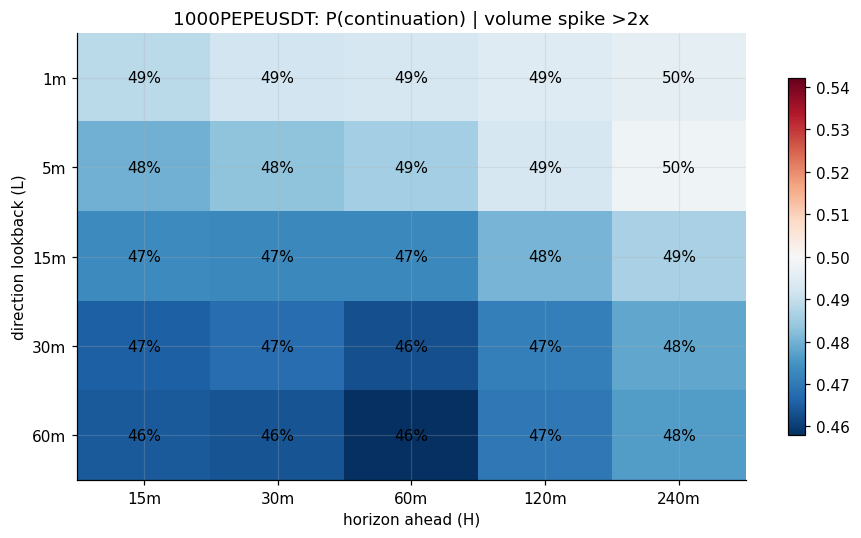

In [3]:
def heat(P, title, center=0.5, fname=None, fmt='{:.0%}'):
    fig, ax = plt.subplots(figsize=(8.5, 5))
    span = max(abs(P - center).max(), 1e-9)
    im = ax.imshow(P, cmap='RdBu_r', vmin=center-span, vmax=center+span, aspect='auto')
    ax.set_xticks(range(len(HORIZONS)));  ax.set_xticklabels([f'{h}m' for h in HORIZONS])
    ax.set_yticks(range(len(LOOKBACKS))); ax.set_yticklabels([f'{l}m' for l in LOOKBACKS])
    ax.set_xlabel('horizon ahead (H)'); ax.set_ylabel('direction lookback (L)')
    for i in range(P.shape[0]):
        for j in range(P.shape[1]):
            ax.text(j, i, fmt.format(P[i, j]), ha='center', va='center', fontsize=10)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, shrink=0.8)
    if fname: show(fname)

heat(P_cond, f'{SYMBOL}: P(continuation) | volume spike >2x', fname='03_cont_spike')

## Does the volume spike actually add anything?

Difference vs baseline, in percentage points. **Red = spike makes it more
momentum-y, Blue = spike makes it more reverting.** Near 0 = spike adds nothing.

[saved] notebooks\_out\03_cont_delta.png
baseline P(continuation):
  L=1m   15m:49.1%  30m:49.2%  60m:49.4%  120m:49.6%  240m:49.7%
  L=5m   15m:48.5%  30m:48.8%  60m:48.9%  120m:49.5%  240m:49.8%
  L=15m  15m:47.9%  30m:48.3%  60m:48.4%  120m:49.1%  240m:49.5%
  L=30m  15m:48.2%  30m:48.2%  60m:48.5%  120m:48.8%  240m:49.3%
  L=60m  15m:48.2%  30m:48.2%  60m:48.1%  120m:48.8%  240m:49.2%


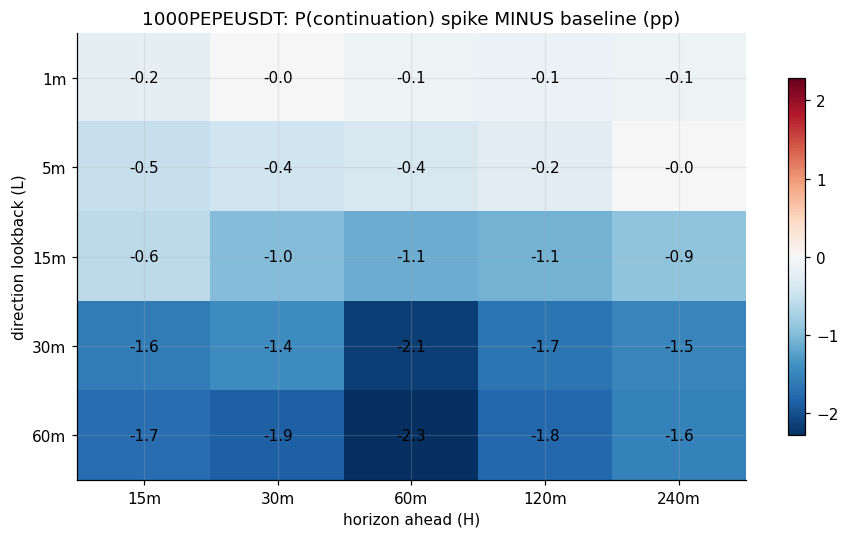

In [4]:
delta = (P_cond - P_base) * 100
heat(delta, f'{SYMBOL}: P(continuation) spike MINUS baseline (pp)',
     center=0.0, fname='03_cont_delta', fmt='{:+.1f}')
print('baseline P(continuation):')
for i, L in enumerate(LOOKBACKS):
    print('  L=' + f'{L}m'.ljust(4), '  '.join(f'{h}m:{P_base[i,j]*100:.1f}%' for j,h in enumerate(HORIZONS)))

## The tradeable number: signed forward return

Win-rate ignores how big the moves are. Here we sign the forward return by the
recent direction (so positive = the bet paid off) and average it — conditional
on the volume spike.

In [5]:
print('mean SIGNED forward return (%), conditional on volume spike >2x:')
print('  (positive = following the recent direction made money, before costs)\n')
print('   L \\ H ', '  '.join(f'{h:>7}m' for h in HORIZONS))
for L in LOOKBACKS:
    d = np.sign(close.pct_change(L))
    row = []
    for H in HORIZONS:
        f = close.shift(-H) / close - 1.0
        ok = spike & d.notna() & f.notna() & (d != 0)
        row.append((d[ok] * f[ok]).mean() * 100)
    print(f'  {L:>3}m ', '  '.join(f'{v:>+7.3f}' for v in row))

mean SIGNED forward return (%), conditional on volume spike >2x:
  (positive = following the recent direction made money, before costs)

   L \ H       15m       30m       60m      120m      240m
    1m   -0.011   -0.011   -0.014   -0.012   -0.010
    5m   -0.009   -0.004   -0.019   -0.005   -0.003
   15m   -0.009   -0.003   -0.019   -0.020   -0.015
   30m   -0.009   -0.003   -0.019   -0.025   -0.029
   60m   -0.008   -0.003   -0.010   -0.005   +0.008
